# 🤖 Model 1: KNN - User-based Collaborative Filtering

**Mục tiêu:** Tìm người dùng có cùng đặc điểm cá nhân (Tuổi, Thành phố) để gợi ý bài hát họ thích.

**Bài toán:** Binary Classification — Dự đoán `target` (0 hoặc 1) dựa trên đặc điểm cá nhân người dùng.

**Thư viện:** Scikit-learn (KNeighborsClassifier)

## 2.1.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    mean_squared_error, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2.1.2 Load dữ liệu đã xử lý

In [2]:
df = pd.read_csv('processed_data/merged_data.csv')
print(f'📁 Dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'\n📋 Các cột: {list(df.columns)}')
print(f'\n📊 Phân phối target:')
print(df['target'].value_counts())
print(f'\n   Tỷ lệ target=1: {df["target"].mean()*100:.1f}%')

📁 Dữ liệu: 100,000 dòng × 19 cột

📋 Các cột: ['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'target', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'expiration_date', 'song_length', 'genre_ids', 'artist_name', 'composer', 'lyricist', 'language', 'song_name']

📊 Phân phối target:
target
1    50597
0    49403
Name: count, dtype: int64

   Tỷ lệ target=1: 50.6%


## 2.1.3 Chuẩn bị Features cho KNN

**Ý tưởng:** KNN User-based sử dụng đặc điểm cá nhân của người dùng để tìm những người dùng "tương tự".

Nếu hai người dùng có cùng độ tuổi, cùng thành phố → họ có khả năng thích cùng loại nhạc.

**Features sử dụng:**
- `city` — Thành phố của người dùng
- `bd` — Tuổi của người dùng
- `gender` — Giới tính (encode thành số)
- `registered_via` — Kênh đăng ký
- `language` — Ngôn ngữ bài hát

**Target:** `target` (0 = không thích, 1 = thích)

In [3]:
# Chọn features cho KNN
feature_cols = ['city', 'bd', 'gender', 'registered_via', 'language']

# Encode cột gender (chuyển text → số)
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'].astype(str))

# Tạo ma trận features X và target y
X = df[feature_cols].copy()
y = df['target'].copy()

print(f'✅ Features shape: {X.shape}')
print(f'✅ Target shape:   {y.shape}')
print(f'\n📋 Feature columns: {feature_cols}')
print(f'\n📊 Thống kê features:')
X.describe()

✅ Features shape: (100000, 5)
✅ Target shape:   (100000,)

📋 Feature columns: ['city', 'bd', 'gender', 'registered_via', 'language']

📊 Thống kê features:


,city,bd,gender,registered_via,language
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,7.547210,28.004260,0.713710,6.78628,18.627720
std,6.671566,6.701153,0.452029,2.28177,21.191256
min,1.000000,2.000000,0.000000,3.00000,-1.000000
25%,1.000000,26.000000,0.000000,4.00000,3.000000
50%,5.000000,27.000000,1.000000,7.00000,3.000000
75%,13.000000,29.000000,1.000000,9.00000,52.000000
max,22.000000,95.000000,1.000000,13.00000,59.000000


## 2.1.4 Chuẩn hóa Features (StandardScaler)

KNN tính khoảng cách giữa các điểm dữ liệu → cần chuẩn hóa để các features có cùng thang đo.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Đã chuẩn hóa features bằng StandardScaler')
print(f'   Mean sau chuẩn hóa: {X_scaled.mean(axis=0).round(4)}')
print(f'   Std sau chuẩn hóa:  {X_scaled.std(axis=0).round(4)}')

✅ Đã chuẩn hóa features bằng StandardScaler
   Mean sau chuẩn hóa: [ 0.  0.  0.  0. -0.]
   Std sau chuẩn hóa:  [1. 1. 1. 1. 1.]


## 2.1.5 Chia dữ liệu Train/Test (80/20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 Chia dữ liệu:')
print(f'   Train: {X_train.shape[0]:,} mẫu ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]:,} mẫu ({X_test.shape[0]/len(y)*100:.0f}%)')
print(f'\n   Tỷ lệ target=1 (Train): {y_train.mean()*100:.1f}%')
print(f'   Tỷ lệ target=1 (Test):  {y_test.mean()*100:.1f}%')

📊 Chia dữ liệu:
   Train: 80,000 mẫu (80%)
   Test:  20,000 mẫu (20%)

   Tỷ lệ target=1 (Train): 50.6%
   Tỷ lệ target=1 (Test):  50.6%


## 2.1.6 Tìm K tối ưu

Thử nhiều giá trị K khác nhau để tìm K cho kết quả tốt nhất.

In [6]:
k_values = range(3, 31, 2)  # K = 3, 5, 7, ..., 29
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f'  K={k:2d} → Accuracy: {acc:.4f}')

best_k = list(k_values)[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f'\n🏆 K tối ưu: {best_k} (Accuracy = {best_acc:.4f})')

  K= 3 → Accuracy: 0.5278
  K= 5 → Accuracy: 0.5302
  K= 7 → Accuracy: 0.5285
  K= 9 → Accuracy: 0.5333
  K=11 → Accuracy: 0.5325
  K=13 → Accuracy: 0.5344
  K=15 → Accuracy: 0.5323
  K=17 → Accuracy: 0.5347
  K=19 → Accuracy: 0.5334
  K=21 → Accuracy: 0.5324
  K=23 → Accuracy: 0.5334
  K=25 → Accuracy: 0.5335
  K=27 → Accuracy: 0.5336
  K=29 → Accuracy: 0.5320

🏆 K tối ưu: 17 (Accuracy = 0.5347)


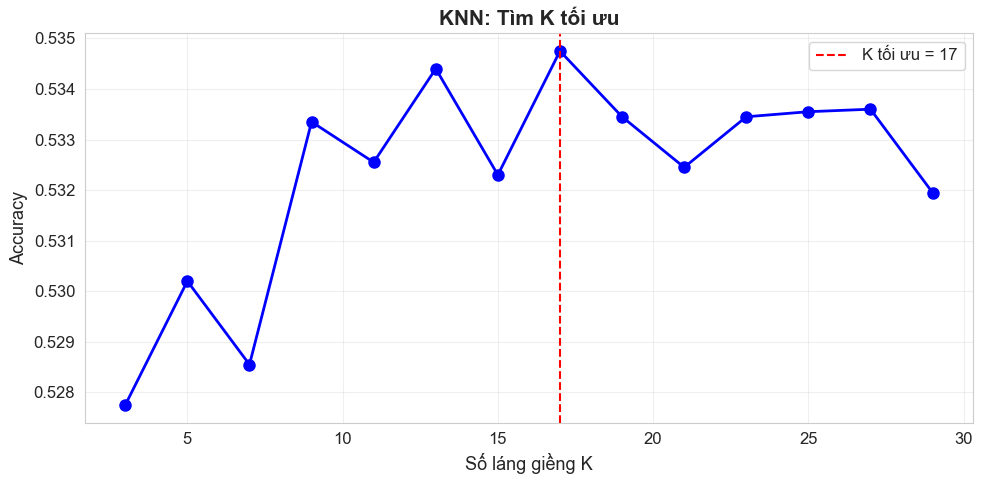

In [7]:
# Biểu đồ K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), accuracies, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K tối ưu = {best_k}')
plt.xlabel('Số láng giềng K', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('KNN: Tìm K tối ưu', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('processed_data/knn_k_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.1.7 Huấn luyện Model KNN với K tối ưu

In [8]:
# Huấn luyện model với K tối ưu
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train, y_train)

# Dự đoán
y_pred = knn_model.predict(X_test)

print(f'✅ Đã huấn luyện KNN với K = {best_k}')
print(f'   Số mẫu train: {X_train.shape[0]:,}')
print(f'   Số mẫu test:  {X_test.shape[0]:,}')

✅ Đã huấn luyện KNN với K = 17
   Số mẫu train: 80,000
   Số mẫu test:  20,000


## 2.1.8 Đánh giá Model

Sử dụng 4 chỉ số: **Accuracy, Precision, Recall, RMSE**

In [9]:
# Tính các chỉ số đánh giá
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 50)
print('📊 KẾT QUẢ ĐÁNH GIÁ MODEL KNN (User-based)')
print('=' * 50)
print(f'  K (số láng giềng):  {best_k}')
print(f'  Accuracy:            {acc:.4f}')
print(f'  Precision:           {prec:.4f}')
print(f'  Recall:              {rec:.4f}')
print(f'  RMSE:                {rmse:.4f}')
print('=' * 50)

print(f'\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Không thích (0)', 'Thích (1)']))

📊 KẾT QUẢ ĐÁNH GIÁ MODEL KNN (User-based)
  K (số láng giềng):  17
  Accuracy:            0.5347
  Precision:           0.5355
  Recall:              0.6065
  RMSE:                0.6821

📋 Classification Report:
                 precision    recall  f1-score   support

Không thích (0)       0.53      0.46      0.49      9881
      Thích (1)       0.54      0.61      0.57     10119

       accuracy                           0.53     20000
      macro avg       0.53      0.53      0.53     20000
   weighted avg       0.53      0.53      0.53     20000



## 2.1.9 Confusion Matrix

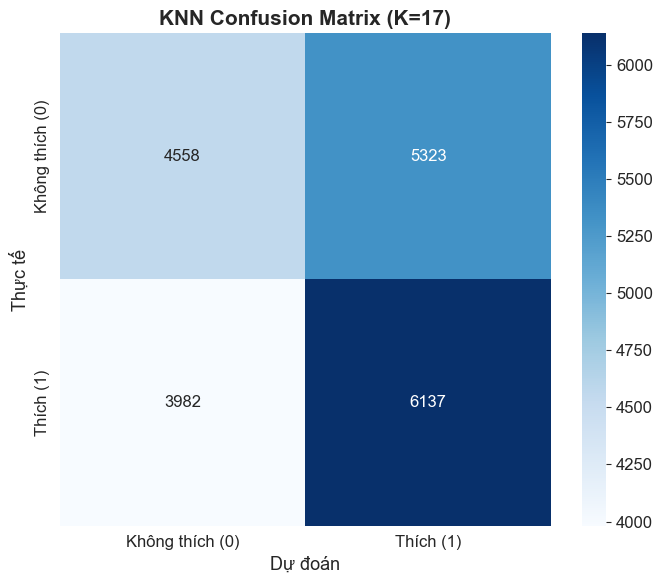


📊 Chi tiết Confusion Matrix:
  True Negative  (TN): 4,558
  False Positive (FP): 5,323
  False Negative (FN): 3,982
  True Positive  (TP): 6,137


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không thích (0)', 'Thích (1)'],
            yticklabels=['Không thích (0)', 'Thích (1)'])
plt.xlabel('Dự đoán', fontsize=13)
plt.ylabel('Thực tế', fontsize=13)
plt.title(f'KNN Confusion Matrix (K={best_k})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('processed_data/knn_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Chi tiết Confusion Matrix:')
print(f'  True Negative  (TN): {cm[0][0]:,}')
print(f'  False Positive (FP): {cm[0][1]:,}')
print(f'  False Negative (FN): {cm[1][0]:,}')
print(f'  True Positive  (TP): {cm[1][1]:,}')

## 2.1.10 Lưu kết quả đánh giá

Lưu kết quả để so sánh với Model 2 (SVD) và Model 3 (Content-Based) ở bước sau.

In [11]:
# Lưu kết quả đánh giá ra file CSV
results = pd.DataFrame({
    'Model': ['KNN (User-based)'],
    'K': [best_k],
    'Accuracy': [round(acc, 4)],
    'Precision': [round(prec, 4)],
    'Recall': [round(rec, 4)],
    'RMSE': [round(rmse, 4)]
})

results.to_csv('processed_data/knn_results.csv', index=False)
print('✅ Đã lưu kết quả đánh giá vào processed_data/knn_results.csv')
results

✅ Đã lưu kết quả đánh giá vào processed_data/knn_results.csv


,Model,K,Accuracy,Precision,Recall,RMSE
0,KNN (User-based),17,0.5347,0.5355,0.6065,0.6821


## 2.1.11 Demo: Gợi ý bài hát cho 1 User

Nhập User ID → Hiện thông tin cá nhân → Xuất danh sách 5 bài hát gợi ý.

In [12]:
def recommend_songs_knn(user_id, df, knn_model, scaler, feature_cols, top_n=5):
    """Gợi ý bài hát cho 1 user dựa trên KNN User-based."""
    
    # Lấy thông tin user
    user_data = df[df['msno'] == user_id]
    if user_data.empty:
        print(f'❌ Không tìm thấy User: {user_id}')
        return None
    
    # Hiện thông tin cá nhân
    user_info = user_data.iloc[0]
    print('=' * 60)
    print(f'👤 THÔNG TIN NGƯỜI DÙNG')
    print('=' * 60)
    print(f'  User ID:      {user_id[:20]}...')
    print(f'  Thành phố:    {user_info["city"]}')
    print(f'  Tuổi:         {user_info["bd"]}')
    print(f'  Đăng ký qua:  {user_info["registered_via"]}')
    print('=' * 60)
    
    # Tìm các bài hát user chưa nghe (hoặc không thích)
    # Lấy features của tất cả tương tác trong dataset
    X_all = df[feature_cols].values
    X_all_scaled = scaler.transform(X_all)
    
    # Dự đoán target cho tất cả
    predictions = knn_model.predict(X_all_scaled)
    df_temp = df.copy()
    df_temp['predicted'] = predictions
    
    # Lấy bài hát được dự đoán là thích (predicted=1) mà user tương tự thích
    user_features = user_data[feature_cols].iloc[0:1]
    user_scaled = scaler.transform(user_features)
    
    # Tìm K láng giềng gần nhất
    distances, indices = knn_model.kneighbors(user_scaled)
    
    # Lấy bài hát từ các láng giềng có target=1
    neighbor_songs = []
    for idx in indices[0]:
        row = df.iloc[idx]
        if row['target'] == 1:
            neighbor_songs.append({
                'song_name': row.get('song_name', 'N/A'),
                'artist_name': row.get('artist_name', 'N/A'),
                'genre_ids': row.get('genre_ids', 'N/A'),
                'language': row.get('language', 'N/A')
            })
    
    # Nếu không đủ từ KNN neighbors, lấy thêm
    if len(neighbor_songs) < top_n:
        # Mở rộng tìm kiếm trong training set
        similar_mask = (
            (df['city'] == user_info['city']) & 
            (df['target'] == 1)
        )
        extra = df[similar_mask].head(top_n * 2)
        for _, row in extra.iterrows():
            if len(neighbor_songs) >= top_n:
                break
            song = {
                'song_name': row.get('song_name', 'N/A'),
                'artist_name': row.get('artist_name', 'N/A'),
                'genre_ids': row.get('genre_ids', 'N/A'),
                'language': row.get('language', 'N/A')
            }
            if song not in neighbor_songs:
                neighbor_songs.append(song)
    
    # Hiển thị kết quả
    print(f'\n🎵 TOP {min(top_n, len(neighbor_songs))} BÀI HÁT GỢI Ý:')
    print('-' * 60)
    for i, song in enumerate(neighbor_songs[:top_n], 1):
        name = str(song['song_name'])[:30] if song['song_name'] != 'N/A' else 'Unknown'
        artist = str(song['artist_name'])[:25] if song['artist_name'] != 'N/A' else 'Unknown'
        print(f'  {i}. {name} — {artist}')
    print('-' * 60)
    
    return neighbor_songs[:top_n]

# Demo: lấy 1 user từ dataset
sample_user = df['msno'].iloc[0]
recommend_songs_knn(sample_user, df, knn_model, scaler, feature_cols)

👤 THÔNG TIN NGƯỜI DÙNG
  User ID:      RGAe8+3OzXCgYYw4LkvH...
  Thành phố:    1
  Tuổi:         27
  Đăng ký qua:  7

🎵 TOP 5 BÀI HÁT GỢI Ý:
------------------------------------------------------------
  1. 바람이 분다 — Teen Top
  2. 我的歌聲裡 (You Exist in My Song) — 曲婉婷 (Wanting Qu)
  3. 世說心語 — 孫燕姿 (Yanzi Sun)
  4. The Art of Fugue| BWV 1080: Ca — Joanna MacGregor
  5. Going Crazy — TWICE
------------------------------------------------------------


[{'song_name': '바람이 분다',
  'artist_name': 'Teen Top',
  'genre_ids': '444',
  'language': np.float64(31.0)},
 {'song_name': '我的歌聲裡 (You Exist in My Song)',
  'artist_name': '曲婉婷 (Wanting\xa0Qu)',
  'genre_ids': '458',
  'language': np.float64(3.0)},
 {'song_name': '世說心語',
  'artist_name': '孫燕姿 (Yanzi Sun)',
  'genre_ids': '458',
  'language': np.float64(3.0)},
 {'song_name': 'The Art of Fugue| BWV 1080: Canon alla duodecima',
  'artist_name': 'Joanna MacGregor',
  'genre_ids': '958|786',
  'language': np.float64(-1.0)},
 {'song_name': 'Going Crazy',
  'artist_name': 'TWICE',
  'genre_ids': '444',
  'language': np.float64(31.0)}]

## ✅ Kết luận Model 1 (KNN User-based)

- **Phương pháp:** KNN với đặc điểm cá nhân người dùng (Tuổi, Thành phố, Giới tính, Kênh đăng ký, Ngôn ngữ)
- **K tối ưu:** Được tìm qua thử nghiệm
- **Đánh giá:** Accuracy, Precision, Recall, RMSE
- **Kết quả:** Đã lưu vào `processed_data/knn_results.csv` để so sánh với 2 model còn lại